# F11-ML (núcleo) — XGBoost y LightGBM sobre `data/gold/matriz_nucleo.csv`

Tercera versión de este entrenamiento: primero `dataset_maestro.csv` (diario, 24 modelos/hora),
luego `dataset_horario.csv` (un modelo con `hora` como feature), y ahora `matriz_nucleo.csv` --
la matriz depurada del equipo (`scripts/construir_matriz.py` + `depurar_matriz.py` +
`auditoria_frontera.py`), 133 columnas, 0 nulos, apagón de abril-2025 imputado y marcado en vez
de excluido, meteorología con previsión ECMWF real desde 2024-04 (pseudo-previsión antes).

**Ventaja frente a `dataset_horario.csv`:** la columna `split` ya viene calculada en el fichero
-- no hace falta reconstruir el corte train/val/test a mano.

**Rigor añadido tras revisar `notebooks/06_modelos_finales.ipynb` de Sergio:** ese notebook
entrena cada familia con **3 semillas** (media ± desviación, nunca una sola corrida) y calcula el
**salto val→test** para detectar sobreajuste al periodo de validación antes de creerse el ranking.
Aquí se aplica lo mismo a XGBoost y LightGBM -- mismo espíritu, sin tocar el pipeline compartido
de Sergio (`scripts/entrenar_finales.py` sigue intacto). Mismas funciones de evaluación que
`F11_baselines.ipynb`, mismo listón.

In [11]:
import os
from pathlib import Path

_raiz = Path.cwd().resolve()
while not (_raiz / "data" / "gold").is_dir() and _raiz != _raiz.parent:
    _raiz = _raiz.parent
os.chdir(_raiz / "modelos")
print("cwd:", Path.cwd())

GOLD = _raiz / "data" / "gold"
TEMP = _raiz / "data_temp"

cwd: /Users/magui/git/edev_models/modelos


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)

TRAIN_END = pd.Timestamp("2024-12-31")
VAL_END = pd.Timestamp("2025-12-31")
TARGET_COLS = [f"price_h{h:02d}" for h in range(24)]

LISTON_MAE = 19.94        # persistencia_d1 (F11_baselines.ipynb)
LISTON_CAPTURA = 91.2     # media_movil_7d (F11_baselines.ipynb)

SEMILLA_BASE = 42          # misma convención que entrenar_finales.py (SEMILLA + s)
SEMILLAS = 3

# Referencias de corridas anteriores, para comparar en los mismos gráficos.
REF_HORARIO = {
    "XGBoost (horario)": {"MAE_val": 12.99, "captura_val": 94.96},
    "LightGBM (horario)": {"MAE_val": 13.25, "captura_val": 94.54},
}
REF_REDES_MAE = {
    "denso (redes)": 12.62,
    "boosting=LightGBM (redes)": 13.28,
    "gru (redes)": 13.38,
    "seq2seq_absoluto (redes)": 14.89,
    "ENSEMBLE (redes, 8 familias)": 11.86,
}

print("Constantes cargadas.")

Constantes cargadas.


## Evaluación

In [2]:
def tramo(idx: pd.DatetimeIndex) -> pd.Series:
    etiquetas = np.select(
        [idx <= TRAIN_END, idx <= VAL_END], ["train", "val"], default="test",
    )
    return pd.Series(etiquetas, index=idx)


def errores(pred: pd.DataFrame, real: pd.DataFrame) -> pd.DataFrame:
    comun = pred.dropna(how="all").index.intersection(real.index)
    diferencia = pred.loc[comun] - real.loc[comun]
    etiquetas = tramo(comun)
    filas = []
    for nombre_tramo in ["train", "val", "test"]:
        sub = diferencia[etiquetas == nombre_tramo]
        if sub.empty:
            continue
        valores = sub.stack()
        filas.append({
            "tramo": nombre_tramo, "dias": len(sub),
            "MAE": valores.abs().mean(), "RMSE": np.sqrt((valores ** 2).mean()),
            "sesgo": valores.mean(),
        })
    return pd.DataFrame(filas).set_index("tramo")


def ingreso_arbitraje(pred: pd.DataFrame, real: pd.DataFrame, k: int = 4, eficiencia: float = 0.85) -> pd.Series:
    comun = pred.dropna(how="all").index.intersection(real.index)
    p = pred.loc[comun].to_numpy()
    r = real.loc[comun].to_numpy()
    orden = np.argsort(p, axis=1)
    horas_carga, horas_descarga = orden[:, :k], orden[:, -k:]
    coste = np.take_along_axis(r, horas_carga, axis=1).sum(axis=1)
    ingreso = np.take_along_axis(r, horas_descarga, axis=1).sum(axis=1) * eficiencia
    return pd.Series(ingreso - coste, index=comun, name="ingreso")


def evaluar_dinero(pred: pd.DataFrame, real: pd.DataFrame, k: int = 4, eficiencia: float = 0.85) -> pd.DataFrame:
    ingreso = ingreso_arbitraje(pred, real, k, eficiencia)
    perfecto = ingreso_arbitraje(real, real, k, eficiencia)
    comun = ingreso.index.intersection(perfecto.index)
    ingreso, perfecto = ingreso.loc[comun], perfecto.loc[comun]
    etiquetas = tramo(comun)
    filas = []
    for nombre_tramo in ["train", "val", "test"]:
        mascara = etiquetas == nombre_tramo
        if not mascara.any():
            continue
        filas.append({
            "tramo": nombre_tramo, "dias": int(mascara.sum()),
            "ingreso_dia": ingreso[mascara].mean(), "techo_dia": perfecto[mascara].mean(),
            "capturado_%": 100 * ingreso[mascara].sum() / perfecto[mascara].sum(),
            "dias_en_perdida_%": 100 * (ingreso[mascara] < 0).mean(),
        })
    return pd.DataFrame(filas).set_index("tramo")


print("Funciones de evaluación listas.")

Funciones de evaluación listas.


## Carga de datos

`matriz_nucleo.csv` ya trae `split` calculado. Columnas de control (`fecha_pred`, `fecha_objetivo`,
`ts`, `split`, `hora`) y el objetivo (`target_price`) se excluyen de las features; el resto (127
columnas) entra tal cual -- son columnas ya depuradas y auditadas contra fuga por el equipo
(`auditoria_frontera.py`), así que no se vuelve a filtrar aquí.

In [ ]:
ruta_csv = GOLD / "matriz_nucleo.csv"BlockingIOError
df = pd.read_csv(ruta_csv, parse_dates=["fecha_pred", "fecha_objetivo", "ts"])
print(f"{df.shape[0]} filas x {df.shape[1]} columnas -- nulos: {df.isna().sum().sum()}")

CONTROL = ["fecha_pred", "fecha_objetivo", "ts", "split", "hora"]
TARGET = "target_price"
feature_cols = [c for c in df.columns if c not in CONTROL + [TARGET]]
print(f"{len(feature_cols)} columnas de features")
print(df["split"].value_counts())

mask_train = df["split"] == "train"
mask_resto = df["split"].isin(["validation", "test"])

X_train = df.loc[mask_train, feature_cols]
y_train = df.loc[mask_train, TARGET]
X_resto = df.loc[mask_resto, feature_cols]

# Precio real en formato ancho (fecha_objetivo x hora) -- para reusar errores()/ingreso_arbitraje().
P = df.pivot_table(index="fecha_objetivo", columns="hora", values="target_price")
P.columns = [f"price_h{int(h):02d}" for h in P.columns]
P = P[TARGET_COLS]
print(f"P (precio ancho): {P.shape}")


def pivotear_pred(pred_serie: pd.Series, df_resto: pd.DataFrame) -> pd.DataFrame:
    tmp = df_resto[["fecha_objetivo", "hora"]].copy()
    tmp["pred"] = pred_serie.values
    wide = tmp.pivot_table(index="fecha_objetivo", columns="hora", values="pred")
    wide.columns = [f"price_h{int(h):02d}" for h in wide.columns]
    return wide.reindex(columns=TARGET_COLS)

57521 filas x 133 columnas -- nulos: 0
127 columnas de features
split
train         43699
validation     8759
test           5063
Name: count, dtype: int64
P (precio ancho): (2397, 24)


## Baselines (reconstruidos sobre este mismo `P`)

In [4]:
def construir_baselines(P: pd.DataFrame) -> dict:
    baselines = {
        "persistencia_d1": P.shift(1),
        "persistencia_semanal": P.shift(7),
        "perfil_4_semanas": (P.shift(7) + P.shift(14) + P.shift(21) + P.shift(28)) / 4,
        "media_movil_7d": P.shift(1).rolling(7, min_periods=4).mean(),
    }
    media_dia_anterior = P.shift(1).mean(axis=1)
    baselines["plano_d1"] = pd.DataFrame({col: media_dia_anterior for col in P.columns}, index=P.index)
    return baselines


BASELINES = construir_baselines(P)
print(f"{len(BASELINES)} baselines: {list(BASELINES.keys())}")

5 baselines: ['persistencia_d1', 'persistencia_semanal', 'perfil_4_semanas', 'media_movil_7d', 'plano_d1']


## Entrenamiento -- 3 semillas por algoritmo

Cada semilla es un entrenamiento completo e independiente (mismo `random_state` que usa
`entrenar_finales.py`: 42, 43, 44). Se guardan MAE y captura de las tres, en train**val**test, y
al final la media ± desviación por algoritmo -- una sola corrida no dice si una diferencia es
real o ruido (Sergio midió hasta 0,58 de diferencia entre corridas idénticas de sus redes; aquí
se ve si XGBoost/LightGBM son igual de ruidosos o más estables).

In [12]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

ALGORITMOS = {
    "XGBoost": (XGBRegressor, dict(n_estimators=800, learning_rate=0.03, max_depth=6,
                                    subsample=0.8, colsample_bytree=0.8, n_jobs=-1)),
    "LightGBM": (LGBMRegressor, dict(n_estimators=1000, learning_rate=0.03, num_leaves=63,
                                      subsample=0.8, colsample_bytree=0.8, verbose=-1)),
}

filas_semilla = []
preds_semilla = {}       # (algoritmo, semilla) -> DataFrame ancho de predicciones
importancias_semilla = {}

for algo, (cls, kwargs) in ALGORITMOS.items():
    for s in range(SEMILLAS):
        semilla = SEMILLA_BASE + s
        modelo = cls(**kwargs, random_state=semilla)
        modelo.fit(X_train, y_train)

        pred_h = pd.Series(modelo.predict(X_resto), index=df.loc[mask_resto].index)
        pred_wide = pivotear_pred(pred_h, df.loc[mask_resto])
        err = errores(pred_wide, P)
        din = evaluar_dinero(pred_wide, P)

        fila = {
            "algoritmo": algo, "semilla": semilla,
            "MAE_val": err.loc["val", "MAE"] if "val" in err.index else np.nan,
            "MAE_test": err.loc["test", "MAE"] if "test" in err.index else np.nan,
            "captura_val_%": din.loc["val", "capturado_%"] if "val" in din.index else np.nan,
            "captura_test_%": din.loc["test", "capturado_%"] if "test" in din.index else np.nan,
        }
        filas_semilla.append(fila)
        preds_semilla[(algo, semilla)] = pred_wide
        importancias_semilla[(algo, semilla)] = pd.Series(modelo.feature_importances_, index=feature_cols)

        print(f"{algo:10s} s{semilla}  MAE val {fila['MAE_val']:6.2f}  test {fila['MAE_test']:6.2f}"
              f"   captura val {fila['captura_val_%']:5.1f}%  test {fila['captura_test_%']:5.1f}%")

por_semilla = pd.DataFrame(filas_semilla)
out_semilla = GOLD / "matriz_nucleo.csv"
por_semilla.to_csv(out_semilla, index=False)
print(f"\nGuardado: {out_semilla}")

XGBoost    s42  MAE val  13.32  test  13.79   captura val  94.4%  test  94.3%
XGBoost    s43  MAE val  13.36  test  14.04   captura val  94.4%  test  94.5%
XGBoost    s44  MAE val  13.04  test  13.56   captura val  94.6%  test  94.7%
LightGBM   s42  MAE val  13.18  test  13.44   captura val  94.6%  test  94.8%
LightGBM   s43  MAE val  13.07  test  13.30   captura val  94.5%  test  95.4%
LightGBM   s44  MAE val  13.22  test  12.95   captura val  94.6%  test  94.9%

Guardado: /Users/magui/git/edev_models/data/gold/matriz_nucleo.csv


### Media, desviación y salto val→test

`salto` = MAE_test − MAE_val. Positivo y grande = el modelo se ajustó al periodo de validación y
generaliza peor de lo que promete -- el mismo chequeo que hace la sección 2 de
`06_modelos_finales.ipynb`.

In [6]:
resumen_semillas = por_semilla.groupby("algoritmo").agg(
    n=("semilla", "size"),
    MAE_val=("MAE_val", "mean"), sd_val=("MAE_val", "std"),
    MAE_test=("MAE_test", "mean"), sd_test=("MAE_test", "std"),
    captura_val=("captura_val_%", "mean"), captura_test=("captura_test_%", "mean"),
).round(3)
resumen_semillas["salto"] = (resumen_semillas["MAE_test"] - resumen_semillas["MAE_val"]).round(3)

print(resumen_semillas.to_string())

for algo, fila in resumen_semillas.iterrows():
    if fila["salto"] > 0.5:
        print(f"\nOJO: {algo} empeora {fila['salto']:+.2f} EUR/MWh al pasar a test "
              f"(sd_val={fila['sd_val']:.2f}). Su puesto en validación no garantiza cómo predice 2026.")
    else:
        print(f"\n{algo}: salto val->test de {fila['salto']:+.2f} EUR/MWh -- estable.")

# Representante de cada algoritmo: la semilla con mejor MAE_val (mismo criterio que
# `06_modelos_finales.ipynb` -- nunca se elige mirando test).
representantes = por_semilla.loc[por_semilla.groupby("algoritmo")["MAE_val"].idxmin()]
print()
print("Representante elegido por MAE de validación:")
print(representantes.round(2).to_string(index=False))

pred_xgb = preds_semilla[("XGBoost", int(representantes.set_index("algoritmo").loc["XGBoost", "semilla"]))]
pred_lgb = preds_semilla[("LightGBM", int(representantes.set_index("algoritmo").loc["LightGBM", "semilla"]))]
imp_xgb = importancias_semilla[("XGBoost", int(representantes.set_index("algoritmo").loc["XGBoost", "semilla"]))].sort_values(ascending=False)
imp_lgb = importancias_semilla[("LightGBM", int(representantes.set_index("algoritmo").loc["LightGBM", "semilla"]))].sort_values(ascending=False)

mae_val_xgb = errores(pred_xgb, P).loc["val", "MAE"]
cap_val_xgb = evaluar_dinero(pred_xgb, P).loc["val", "capturado_%"]
mae_val_lgb = errores(pred_lgb, P).loc["val", "MAE"]
cap_val_lgb = evaluar_dinero(pred_lgb, P).loc["val", "capturado_%"]

           n  MAE_val  sd_val  MAE_test  sd_test  captura_val  captura_test  salto
algoritmo                                                                         
LightGBM   3   13.154   0.074    13.229    0.248       94.553        95.055  0.075
XGBoost    3   13.243   0.174    13.795    0.239       94.465        94.496  0.552

LightGBM: salto val->test de +0.07 EUR/MWh -- estable.

OJO: XGBoost empeora +0.55 EUR/MWh al pasar a test (sd_val=0.17). Su puesto en validación no garantiza cómo predice 2026.

Representante elegido por MAE de validación:
algoritmo  semilla  MAE_val  MAE_test  captura_val_%  captura_test_%
 LightGBM       43    13.07     13.30          94.52           95.44
  XGBoost       44    13.04     13.56          94.55           94.65


## Resumen vs listón F11, vs `dataset_horario` y vs leaderboard de redes

A partir de aquí se usa el **representante** de cada algoritmo (la semilla con mejor MAE de
validación), igual que hace el ensemble de Sergio con sus 8 familias.

In [ ]:
resumen = pd.DataFrame([
    {"modelo": "XGBoost (núcleo, repr.)", "MAE_val": mae_val_xgb, "captura_val_%": cap_val_xgb},
    {"modelo": "LightGBM (núcleo, repr.)", "MAE_val": mae_val_lgb, "captura_val_%": cap_val_lgb},
    {"modelo": "XGBoost (horario)", "MAE_val": REF_HORARIO["XGBoost (horario)"]["MAE_val"],
     "captura_val_%": REF_HORARIO["XGBoost (horario)"]["captura_val"]},
    {"modelo": "LightGBM (horario)", "MAE_val": REF_HORARIO["LightGBM (horario)"]["MAE_val"],
     "captura_val_%": REF_HORARIO["LightGBM (horario)"]["captura_val"]},
]).set_index("modelo")
resumen["supera_MAE"] = resumen["MAE_val"] < LISTON_MAE
resumen["supera_dinero"] = resumen["captura_val_%"] > LISTON_CAPTURA

print(resumen.round(2).to_string())
print()
print("Leaderboard de redes (MAE_val, misma matriz, para contexto -- captura NO es comparable):")
for nombre, mae in sorted(REF_REDES_MAE.items(), key=lambda x: x[1]):
    print(f"  {nombre:<30} {mae}")

out = GOLD / "resultados_ml_nucleo.csv"
resumen.to_csv(out)
print(f"\nGuardado: {out}")

                          MAE_val  captura_val_%  supera_MAE  supera_dinero
modelo                                                                     
XGBoost (núcleo, repr.)     13.04          94.55        True           True
LightGBM (núcleo, repr.)    13.07          94.52        True           True
XGBoost (horario)           12.99          94.96        True           True
LightGBM (horario)          13.25          94.54        True           True

Leaderboard de redes (MAE_val, misma matriz, para contexto -- captura NO es comparable):
  ENSEMBLE (redes, 8 familias)   11.86
  denso (redes)                  12.62
  boosting=LightGBM (redes)      13.28
  gru (redes)                    13.38
  seq2seq_absoluto (redes)       14.89


OSError: Cannot save file into a non-existent directory: '../data/gold'

## Gráficos

In [ ]:
MODELOS = {**BASELINES, "XGBoost (núcleo)": pred_xgb, "LightGBM (núcleo)": pred_lgb}
COLOR_DESTACADO = {"XGBoost (núcleo)": "#e8622c", "LightGBM (núcleo)": "#3987e5"}
COLOR_REF = "#c9a86a"
COLOR_BASE = "#a8a6a0"

print(f"{len(MODELOS)} modelos en los gráficos: {list(MODELOS.keys())}")

7 modelos en los gráficos: ['persistencia_d1', 'persistencia_semanal', 'perfil_4_semanas', 'media_movil_7d', 'plano_d1', 'XGBoost (núcleo)', 'LightGBM (núcleo)']


### MAE y beneficio capturado -- baselines, ML horario (referencia) y ML núcleo

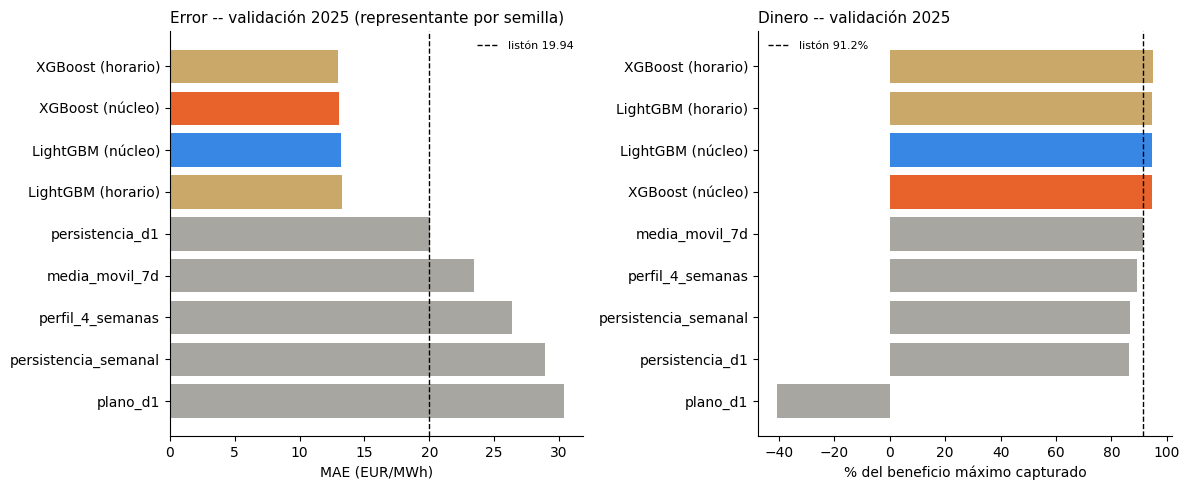

In [ ]:
filas_err, filas_din = [], []
for nombre, pred in MODELOS.items():
    e, d = errores(pred, P), evaluar_dinero(pred, P)
    if "val" in e.index:
        filas_err.append({"modelo": nombre, "MAE": e.loc["val", "MAE"]})
    if "val" in d.index:
        filas_din.append({"modelo": nombre, "capturado_%": d.loc["val", "capturado_%"]})

for nombre, vals in REF_HORARIO.items():
    filas_err.append({"modelo": nombre, "MAE": vals["MAE_val"]})
    filas_din.append({"modelo": nombre, "capturado_%": vals["captura_val"]})

MAE_TODOS = pd.DataFrame(filas_err).set_index("modelo").sort_values("MAE")
DINERO_TODOS = pd.DataFrame(filas_din).set_index("modelo").sort_values("capturado_%", ascending=False)

def color_de(nombre):
    if nombre in COLOR_DESTACADO:
        return COLOR_DESTACADO[nombre]
    if nombre in REF_HORARIO:
        return COLOR_REF
    return COLOR_BASE

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(MAE_TODOS.index, MAE_TODOS["MAE"], color=[color_de(m) for m in MAE_TODOS.index])
axes[0].axvline(LISTON_MAE, color="black", ls="--", lw=1, label=f"listón {LISTON_MAE}")
axes[0].invert_yaxis()
axes[0].set_xlabel("MAE (EUR/MWh)")
axes[0].set_title("Error -- validación 2025 (representante por semilla)", loc="left", fontsize=11)
axes[0].legend(frameon=False, fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(DINERO_TODOS.index, DINERO_TODOS["capturado_%"], color=[color_de(m) for m in DINERO_TODOS.index])
axes[1].axvline(LISTON_CAPTURA, color="black", ls="--", lw=1, label=f"listón {LISTON_CAPTURA}%")
axes[1].invert_yaxis()
axes[1].set_xlabel("% del beneficio máximo capturado")
axes[1].set_title("Dinero -- validación 2025", loc="left", fontsize=11)
axes[1].legend(frameon=False, fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(TEMP / "ml_nucleo_mae_dinero.png", dpi=150, facecolor="white")
plt.show()

### Estabilidad entre semillas -- MAE val vs test por algoritmo

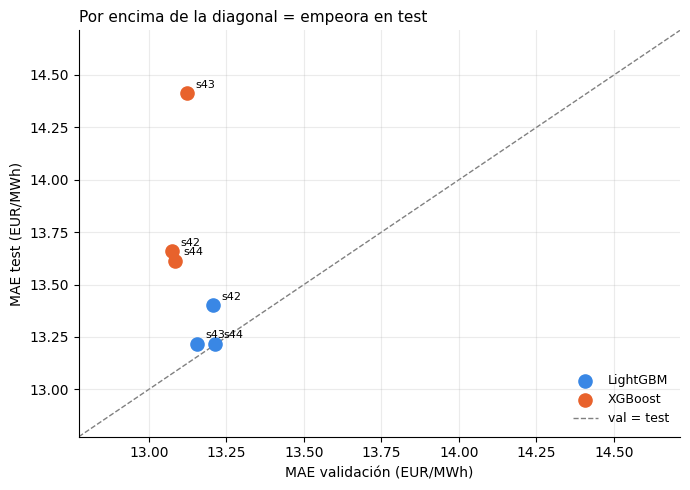

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
colores_algo = {"XGBoost": "#e8622c", "LightGBM": "#3987e5"}

for algo, sub in por_semilla.groupby("algoritmo"):
    ax.scatter(sub["MAE_val"], sub["MAE_test"], s=90, color=colores_algo[algo], label=algo, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(f"s{int(r.semilla)}", (r.MAE_val, r.MAE_test), xytext=(6, 4),
                    textcoords="offset points", fontsize=8)

lims = [min(por_semilla["MAE_val"].min(), por_semilla["MAE_test"].min()) - 0.3,
        max(por_semilla["MAE_val"].max(), por_semilla["MAE_test"].max()) + 0.3]
ax.plot(lims, lims, color="grey", ls="--", lw=1, zorder=1, label="val = test")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("MAE validación (EUR/MWh)")
ax.set_ylabel("MAE test (EUR/MWh)")
ax.set_title("Por encima de la diagonal = empeora en test", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(TEMP / "ml_nucleo_estabilidad_semillas.png", dpi=150, facecolor="white")
plt.show()

### Error por hora del día

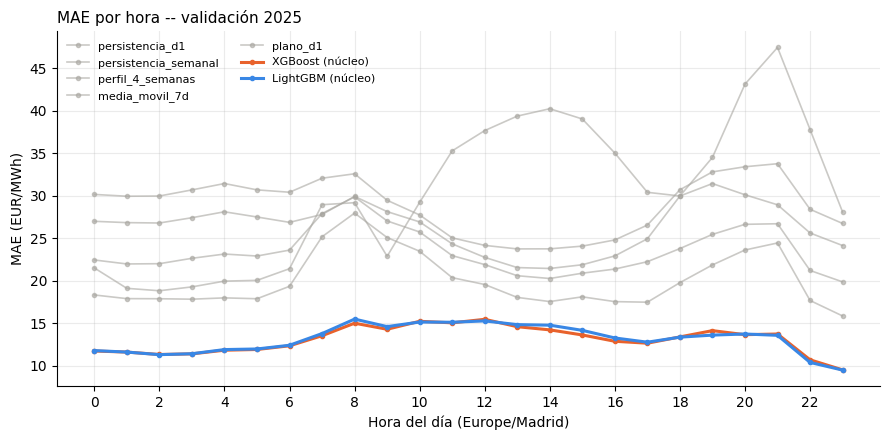

In [ ]:
val_idx = P.index[(P.index > TRAIN_END) & (P.index <= VAL_END)]

por_hora = pd.DataFrame({
    nombre: (pred.loc[pred.index.intersection(val_idx)] - P.loc[val_idx]).abs().mean()
    for nombre, pred in MODELOS.items()
})

fig, ax = plt.subplots(figsize=(9, 4.5))
for col in por_hora.columns:
    destacado = col in COLOR_DESTACADO
    ax.plot(
        range(24), por_hora[col],
        marker="o", markersize=3,
        lw=2.2 if destacado else 1.2,
        color=COLOR_DESTACADO.get(col, COLOR_BASE),
        alpha=1.0 if destacado else 0.6,
        label=col, zorder=3 if destacado else 2,
    )

ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hora del día (Europe/Madrid)")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_title("MAE por hora -- validación 2025", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(TEMP / "ml_nucleo_error_por_hora.png", dpi=150, facecolor="white")
plt.show()

### Importancia de features -- XGBoost vs LightGBM (representante de cada uno)

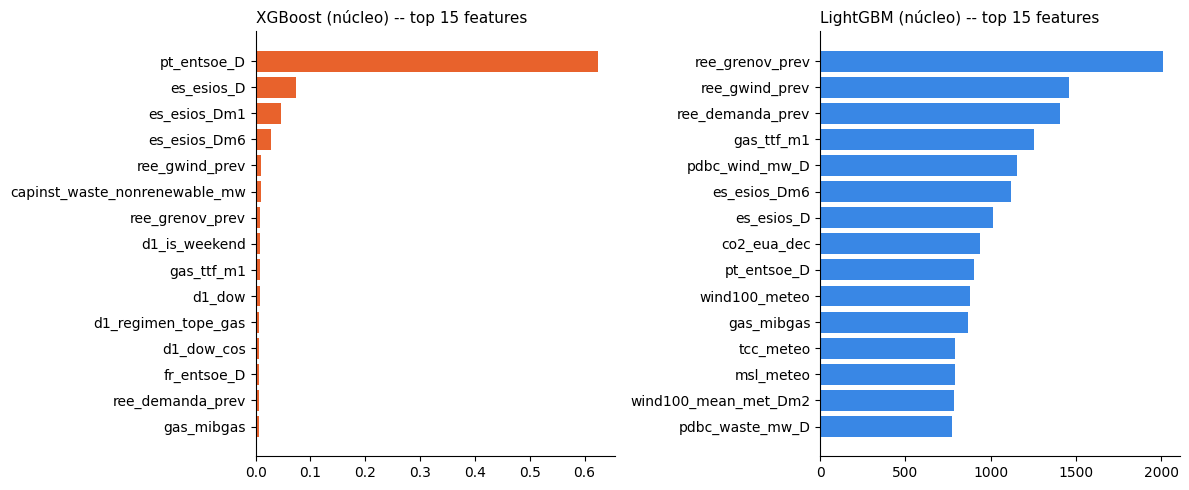

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

top_xgb = imp_xgb.head(15).sort_values()
axes[0].barh(top_xgb.index, top_xgb.values, color=COLOR_DESTACADO["XGBoost (núcleo)"])
axes[0].set_title("XGBoost (núcleo) -- top 15 features", loc="left", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)

top_lgb = imp_lgb.head(15).sort_values()
axes[1].barh(top_lgb.index, top_lgb.values, color=COLOR_DESTACADO["LightGBM (núcleo)"])
axes[1].set_title("LightGBM (núcleo) -- top 15 features", loc="left", fontsize=11)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(TEMP / "ml_nucleo_feature_importance.png", dpi=150, facecolor="white")
plt.show()

### Ingreso acumulado de arbitraje

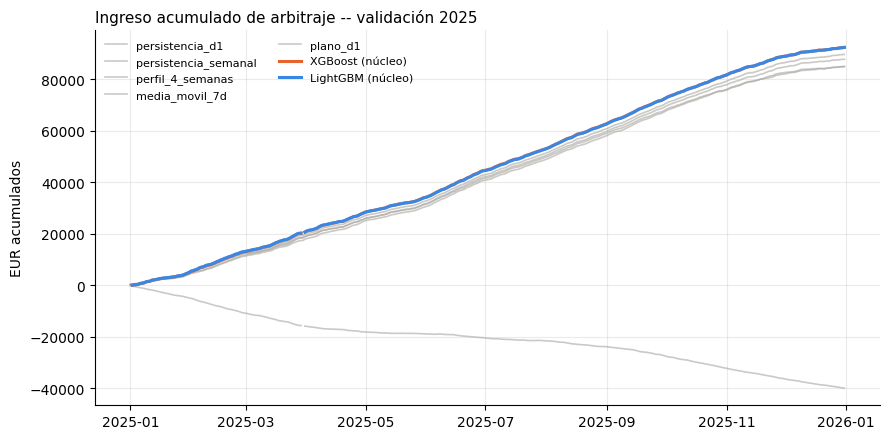

Gráficos guardados en data_temp/: ml_nucleo_mae_dinero.png, ml_nucleo_estabilidad_semillas.png,
ml_nucleo_error_por_hora.png, ml_nucleo_feature_importance.png y ml_nucleo_ingreso_acumulado.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for nombre, pred in MODELOS.items():
    destacado = nombre in COLOR_DESTACADO
    ingreso = ingreso_arbitraje(pred, P)
    ingreso_val = ingreso.loc[ingreso.index.intersection(val_idx)].sort_index()
    ax.plot(
        ingreso_val.index, ingreso_val.cumsum(),
        lw=2.2 if destacado else 1.2,
        color=COLOR_DESTACADO.get(nombre, COLOR_BASE),
        alpha=1.0 if destacado else 0.6,
        label=nombre, zorder=3 if destacado else 2,
    )

ax.set_title("Ingreso acumulado de arbitraje -- validación 2025", loc="left", fontsize=11)
ax.set_ylabel("EUR acumulados")
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(TEMP / "ml_nucleo_ingreso_acumulado.png", dpi=150, facecolor="white")
plt.show()

print("Gráficos guardados en data_temp/: ml_nucleo_mae_dinero.png, ml_nucleo_estabilidad_semillas.png,")
print("ml_nucleo_error_por_hora.png, ml_nucleo_feature_importance.png y ml_nucleo_ingreso_acumulado.png")